In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directories
BASE_CRM = Path("/media/dysco/New Volume/Neeraj/varflexi solver/results/best_result_crm")
BASE_RES = Path("/media/dysco/New Volume/Neeraj/varflexi solver/results/results 2/results-reisner-span")

FIG_DIR = Path("/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/FINAL/notebooks/plots/comparison")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Helper to get subdirectories assuming identical structure
def get_dirs(base_path):
    return {
        "solid": base_path / "solid" / "v18_reissner_mindlin_plate",
        "fluid": base_path / "fluid" / "v9",
        "coupling": base_path / "coupling"
    }

dirs_crm = get_dirs(BASE_CRM)
dirs_res = get_dirs(BASE_RES)

# Plot settings
plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm", "font.size": 10,
    "axes.labelsize": 10, "axes.titlesize": 10, "legend.fontsize": 9, 
    "xtick.labelsize": 8, "ytick.labelsize": 8, "lines.linewidth": 1.2, 
    "axes.linewidth": 0.8, "figure.dpi": 300, "savefig.bbox": "tight"
})

# Load the core diagnostic files for BOTH cases
solid_crm = pd.read_csv(dirs_crm["solid"] / "solid_v18_diagnostics.csv")
fluid_coupling_crm = pd.read_csv(dirs_crm["fluid"] / "fluid_v9_coupling_diagnostics.csv")

solid_res = pd.read_csv(dirs_res["solid"] / "solid_v18_diagnostics.csv")
fluid_coupling_res = pd.read_csv(dirs_res["fluid"] / "fluid_v9_coupling_diagnostics.csv")

print("Both diagnostic datasets loaded successfully.")

Both diagnostic datasets loaded successfully.


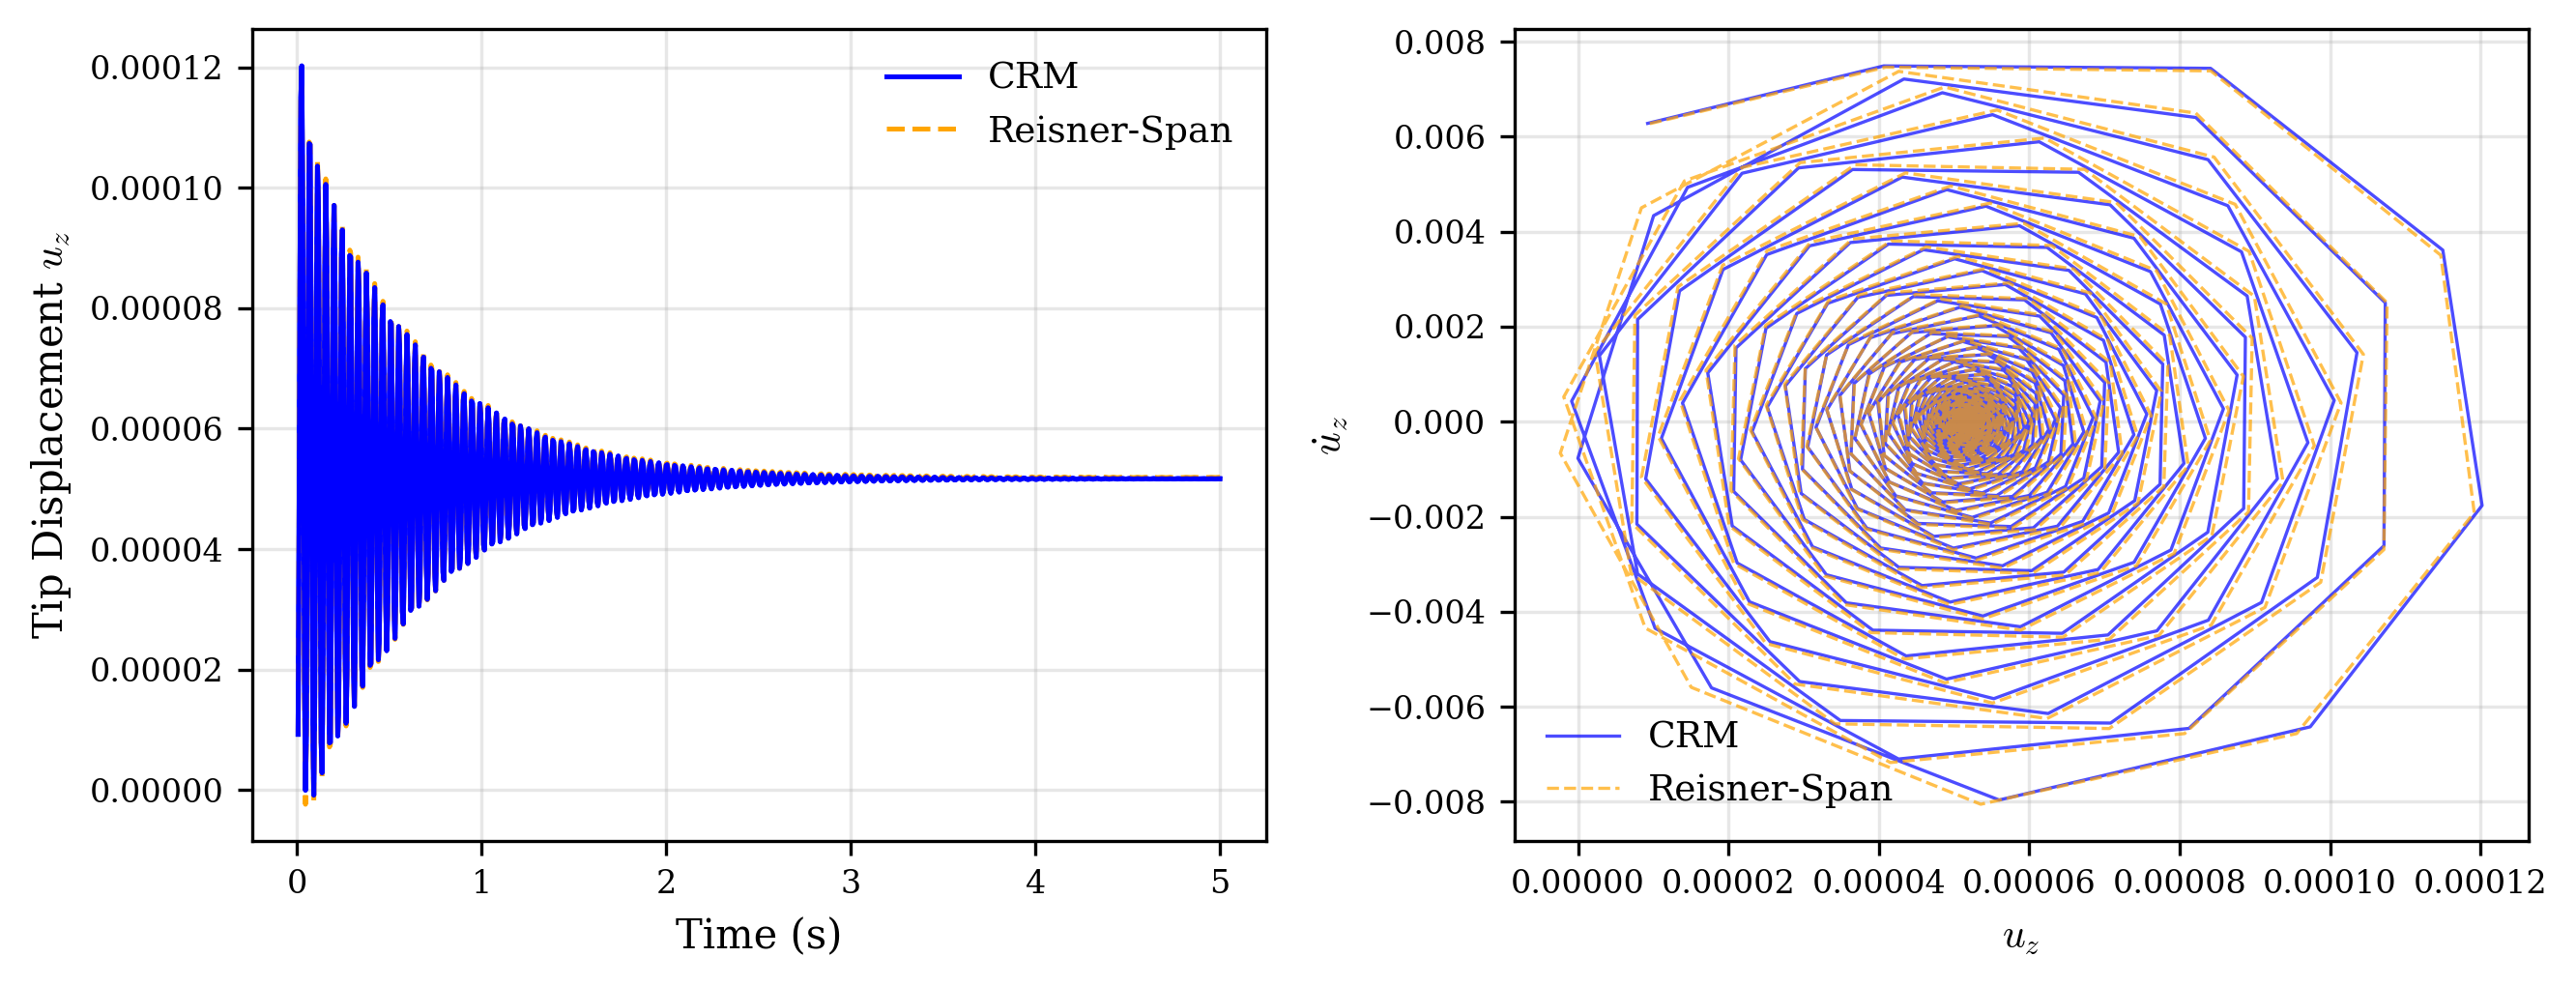

In [2]:
# Extract CRM data
time_crm = solid_crm['time'].values
u_tip_crm = solid_crm['u_tip'].values
v_tip_crm = np.gradient(u_tip_crm, time_crm)

# Extract Reisner-Span data
time_res = solid_res['time'].values
u_tip_res = solid_res['u_tip'].values
v_tip_res = np.gradient(u_tip_res, time_res)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

# Plot 1: Displacement Time History
ax1.plot(time_crm, u_tip_crm, color='b', linestyle='-', label='CRM')
ax1.plot(time_res, u_tip_res, color='orange', linestyle='--', label='Reisner-Span')
ax1.set_xlabel(r"Time (s)")
ax1.set_ylabel(r"Tip Displacement $u_z$")
ax1.grid(True, alpha=0.3)
# plt.xlim(4,5)
ax1.legend(frameon=False)

# Plot 2: Phase Space
ax1.plot(time_crm, u_tip_crm, color='b', linestyle='-', label='CRM')
ax2.plot(u_tip_crm, v_tip_crm, color='b', linestyle='-', linewidth=0.8, alpha=0.7, label='CRM')
ax2.plot(u_tip_res, v_tip_res, color='orange', linestyle='--', linewidth=0.8, alpha=0.7, label='Reisner-Span')
ax2.set_xlabel(r"$u_z$")
ax2.set_ylabel(r"$\dot{u}_z$")
ax2.grid(True, alpha=0.3)
# plt.xlim(4,5)
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_kinematics.pdf")
plt.show()

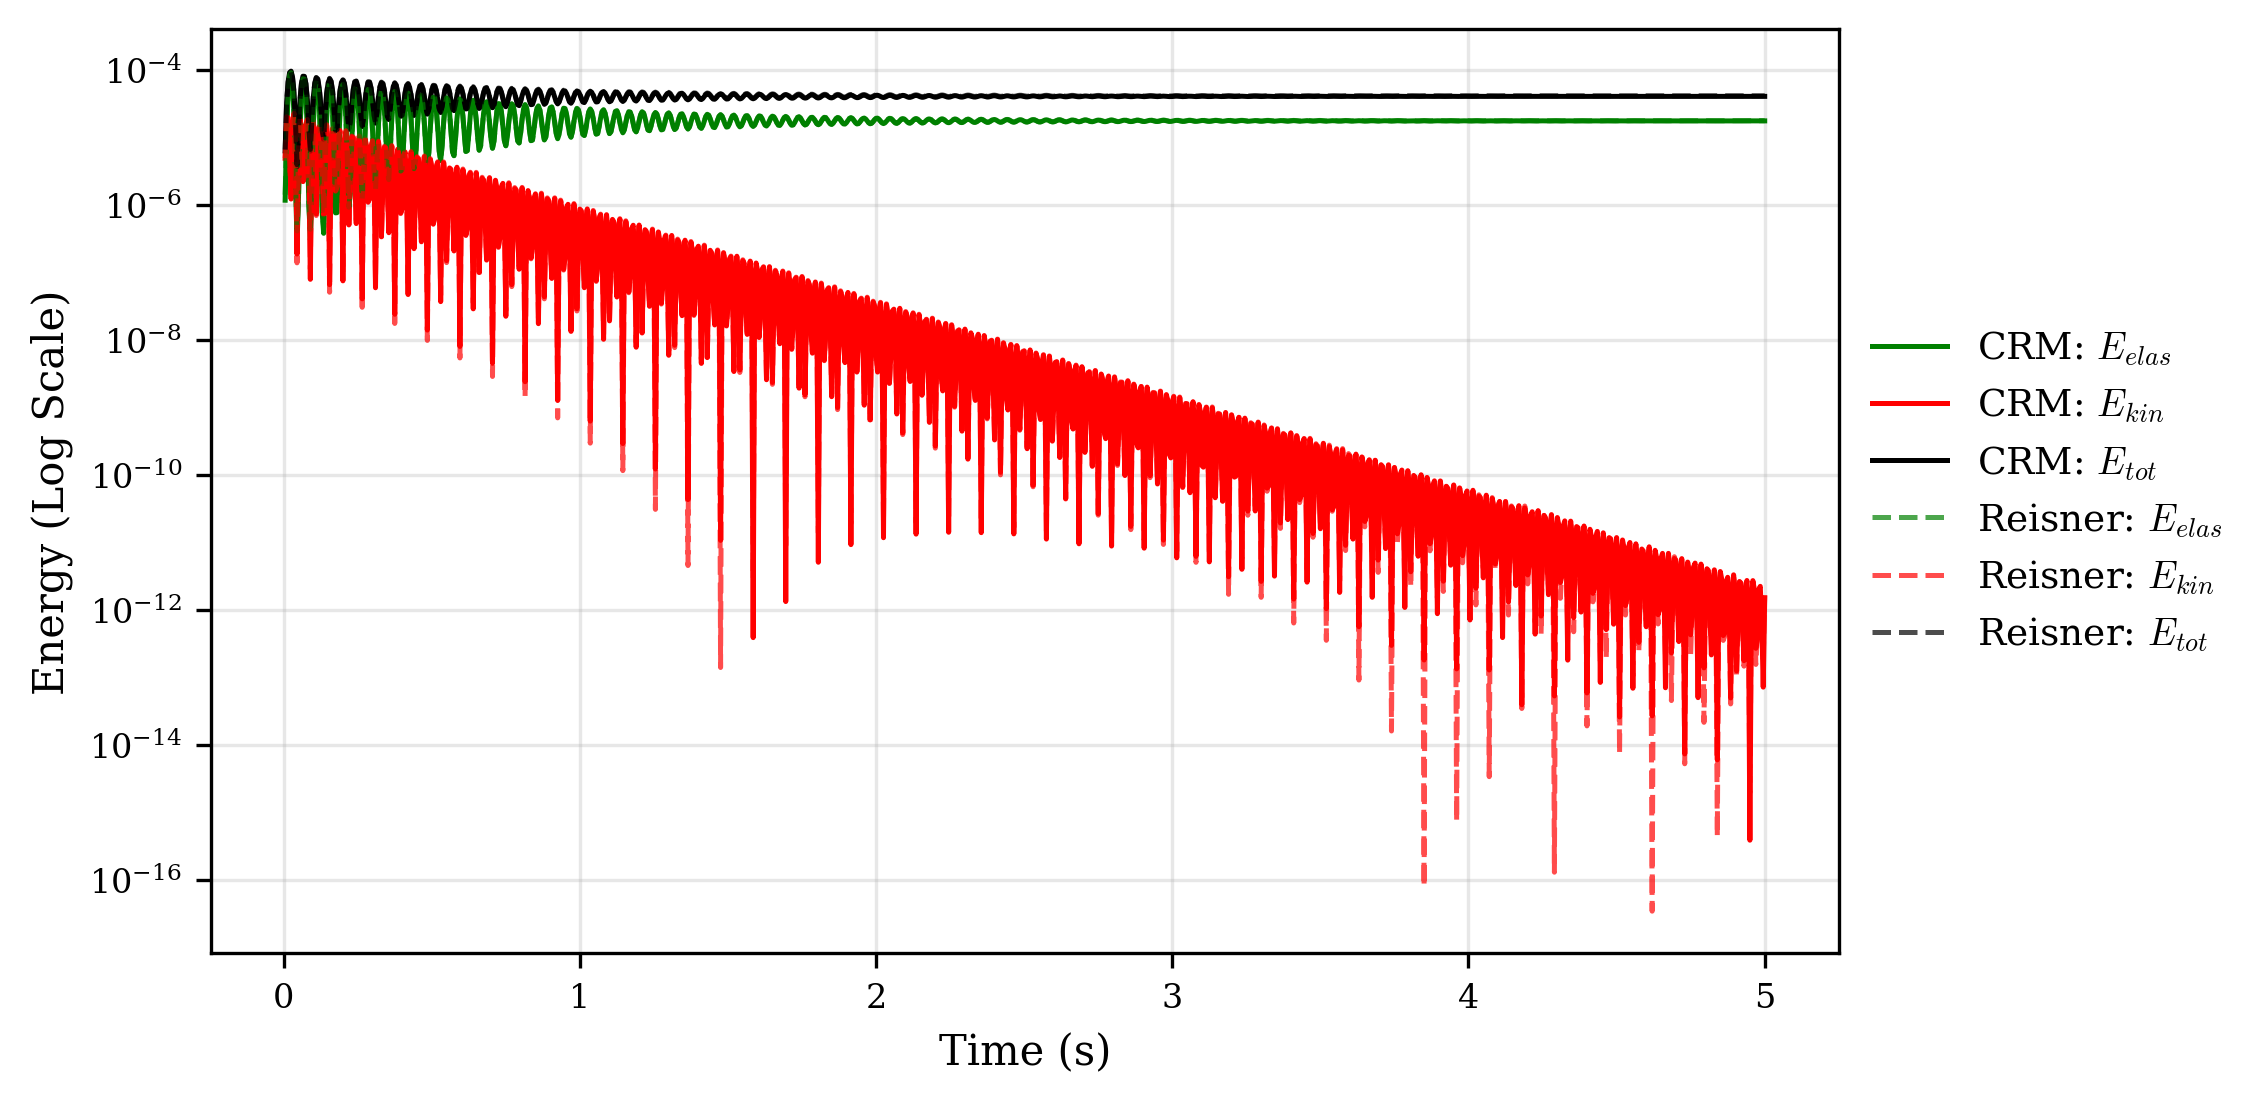

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

# Plot CRM (Solid lines)
ax.semilogy(time_crm, solid_crm['E_elas'], color='g', linestyle='-', label=r"CRM: $E_{elas}$")
ax.semilogy(time_crm, solid_crm['E_kin'], color='r', linestyle='-', label=r"CRM: $E_{kin}$")
ax.semilogy(time_crm, solid_crm['E_tot'], color='k', linestyle='-', label=r"CRM: $E_{tot}$")

# Plot Reisner-Span (Dashed lines)
ax.semilogy(time_res, solid_res['E_elas'], color='g', linestyle='--', alpha=0.7, label=r"Reisner: $E_{elas}$")
ax.semilogy(time_res, solid_res['E_kin'], color='r', linestyle='--', alpha=0.7, label=r"Reisner: $E_{kin}$")
ax.semilogy(time_res, solid_res['E_tot'], color='k', linestyle='--', alpha=0.7, label=r"Reisner: $E_{tot}$")

ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"Energy (Log Scale)")
ax.grid(True, which="both", alpha=0.3)

# Place legend outside to avoid cluttering the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

fig.savefig(FIG_DIR / "comparison_energy_log.pdf", bbox_inches='tight')
plt.show()

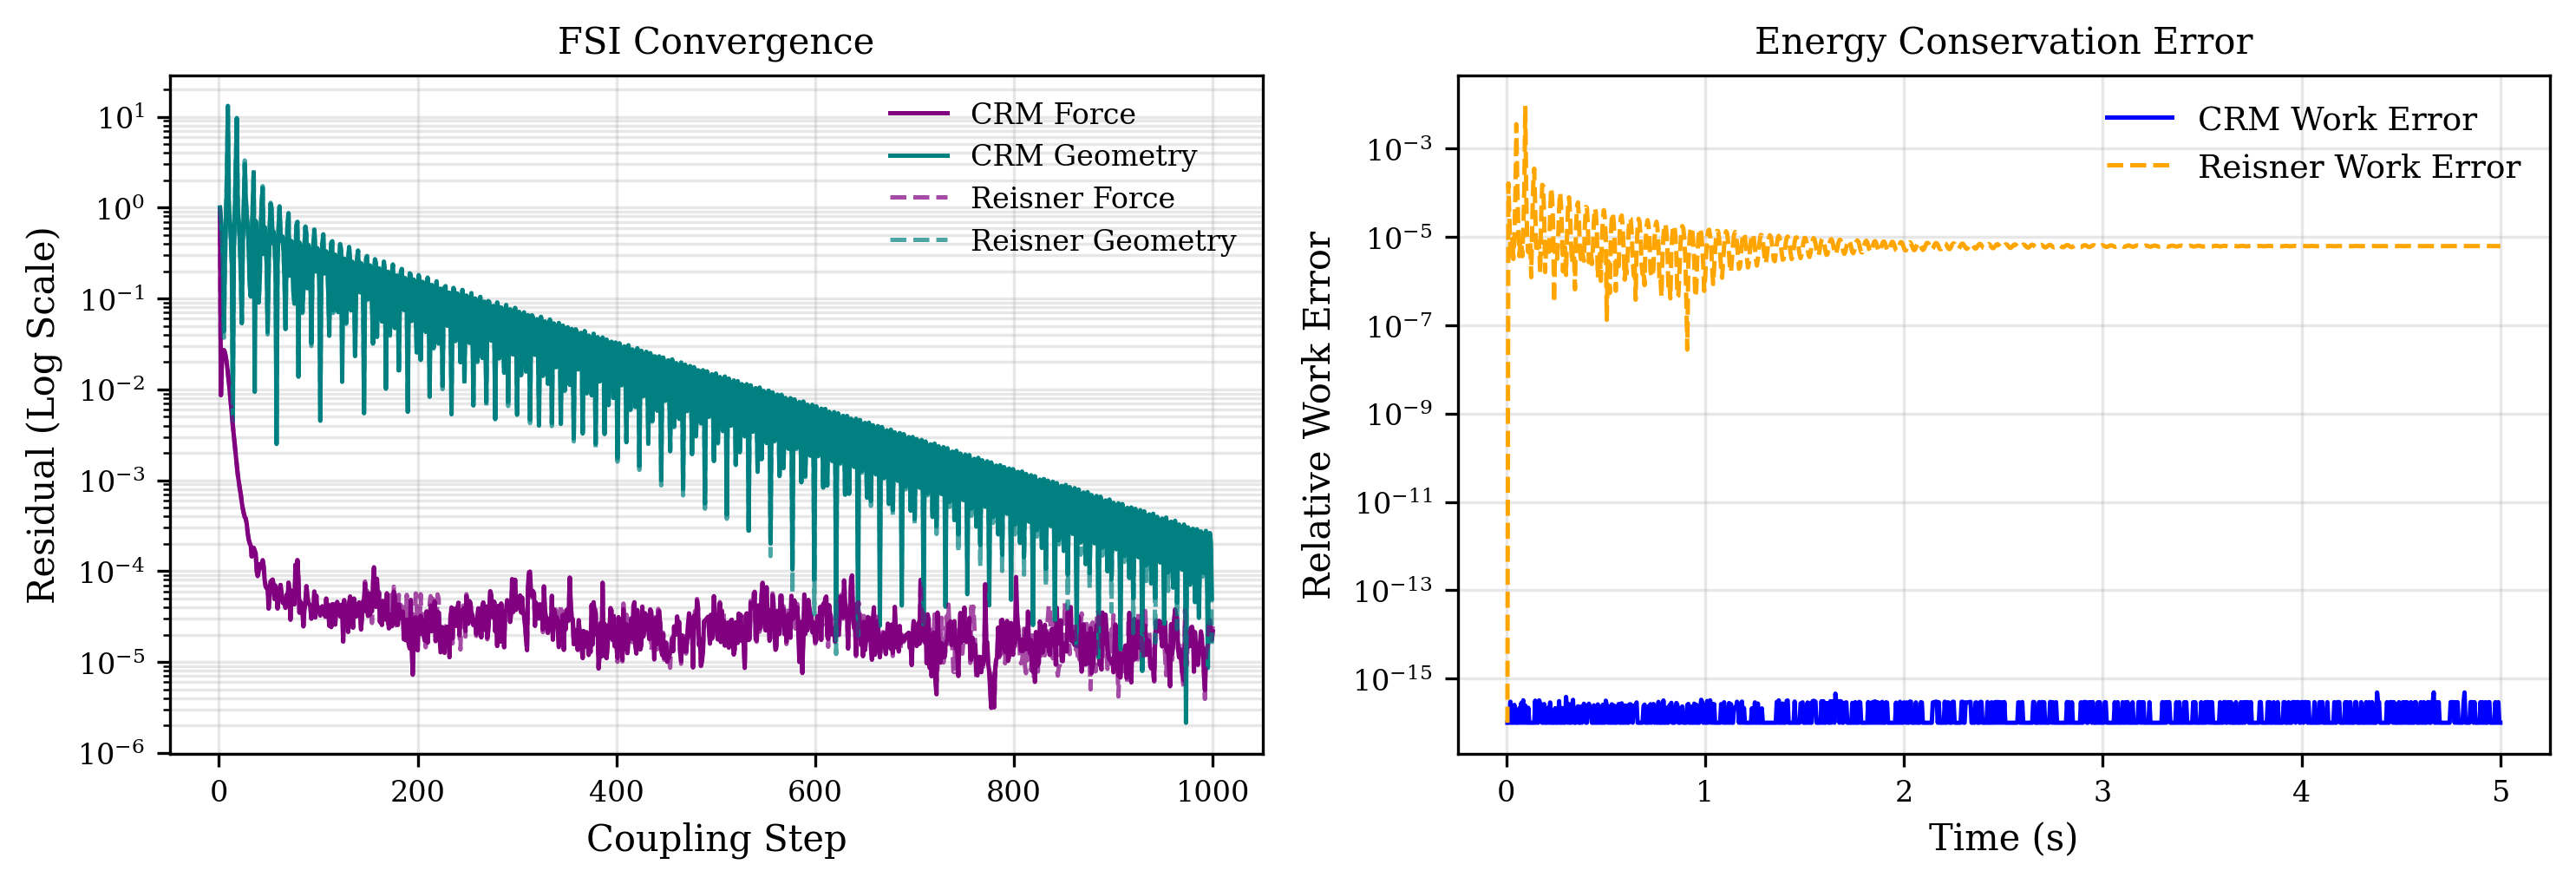

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Plot 1: FSI Coupling Residuals
ax1.semilogy(fluid_coupling_crm['step'], fluid_coupling_crm['force_residual'], color='purple', linestyle='-', label='CRM Force')
ax1.semilogy(fluid_coupling_crm['step'], fluid_coupling_crm['geometry_residual'], color='teal', linestyle='-', label='CRM Geometry')

ax1.semilogy(fluid_coupling_res['step'], fluid_coupling_res['force_residual'], color='purple', linestyle='--', alpha=0.7, label='Reisner Force')
ax1.semilogy(fluid_coupling_res['step'], fluid_coupling_res['geometry_residual'], color='teal', linestyle='--', alpha=0.7, label='Reisner Geometry')

ax1.set_xlabel(r"Coupling Step")
ax1.set_ylabel(r"Residual (Log Scale)")
ax1.set_title("FSI Convergence")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(fontsize=8, frameon=False)

# Plot 2: Solid Solver Work Error
ax2.semilogy(time_crm, solid_crm['work_rel_error'] + 1e-16, color='b', linestyle='-', label='CRM Work Error')
ax2.semilogy(time_res, solid_res['work_rel_error'] + 1e-16, color='orange', linestyle='--', label='Reisner Work Error')

ax2.set_xlabel(r"Time (s)")
ax2.set_ylabel(r"Relative Work Error")
ax2.set_title("Energy Conservation Error")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_solver_diagnostics_log.pdf")
plt.show()

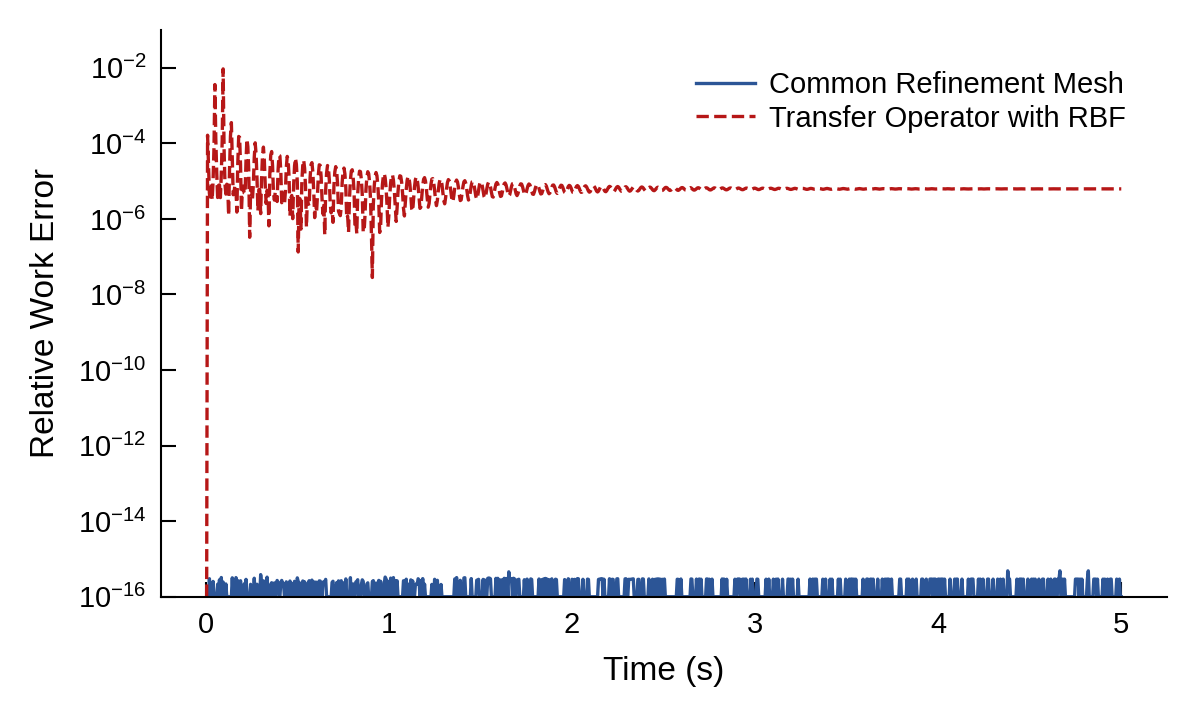

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,            
    "axes.labelsize": 8,       
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,     
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",   
    "ytick.direction": "in",
    "pdf.fonttype": 42,        
    "ps.fonttype": 42
})

COLOR_CRM_WORK = "#2C5596"
COLOR_RES_WORK = "#B61717"

# --- 2. Setup Figure (Wider aspect ratio to match reference image) ---
fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)

# --- 3. Plotting Energy Error ---
h_crm_err, = ax.semilogy(
    time_crm, solid_crm['work_rel_error'] + 1e-16, 
    color=COLOR_CRM_WORK, linestyle="-", linewidth=0.8
)
h_res_err, = ax.semilogy(
    time_res, solid_res['work_rel_error'] + 1e-16, 
    color=COLOR_RES_WORK, linestyle="--", linewidth=0.8
)

# --- 4. Styling Axes, Margins, & Spine Spacing ---
ax.set_xlabel("Time (s)", labelpad=4)
ax.set_ylabel("Relative Work Error", labelpad=4)

# Set clean, static exponential limits to match the reference plot headroom
ax.set_ylim(1e-16, 1e-1) 

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# Legend Layout Configuration (Shifted down and right aligned)
ax.legend(
    handles=[h_crm_err, h_res_err],
    labels=["Common Refinement Mesh", "Transfer Operator with RBF"],
    frameon=False, 
    loc="upper right", 
    handletextpad=0.5,   
    labelspacing=0.2,    
    borderaxespad=1.0  # Moves legend down from the top edge to match reference
)

fig.tight_layout()
fig.savefig(FIG_DIR / "work_cons.pdf")

plt.show()


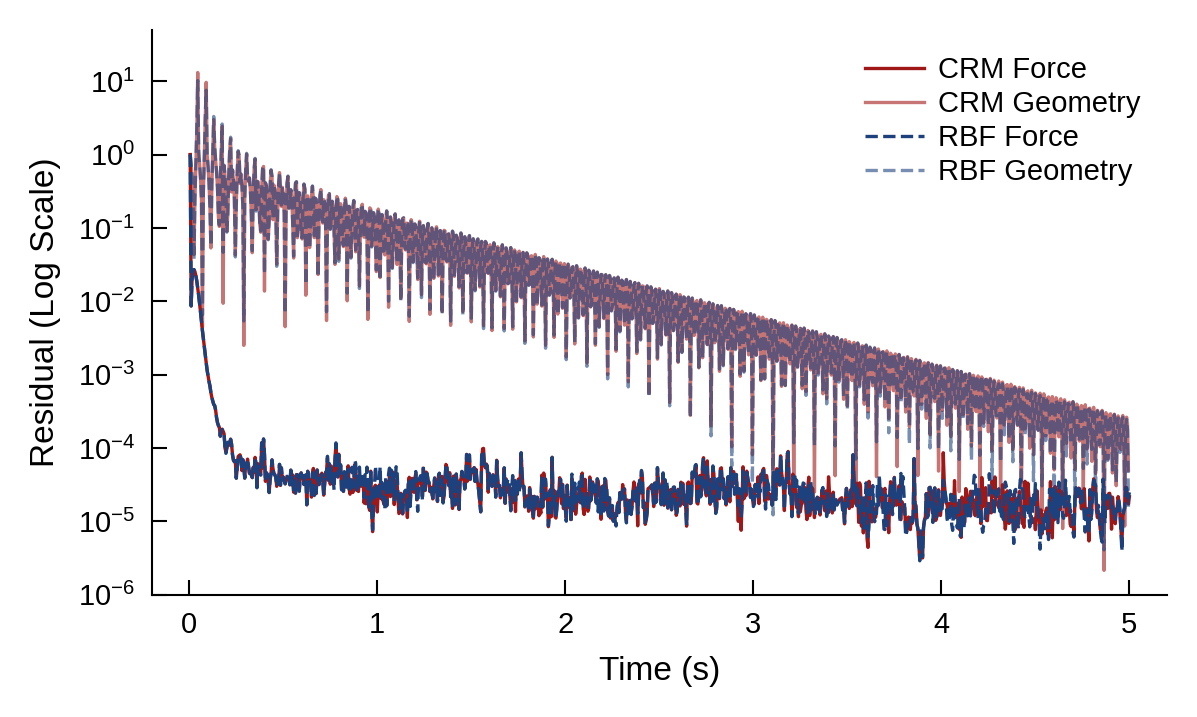

In [22]:
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# --- Color Palette Assignment ---
COLOR_CRM = "#A01717"
COLOR_RBF = "#1C417D"

# --- 2. Convert Coupling Step to Physical Time ---
# 1000 coupling steps correspond to 5 seconds
dt = 0.005  # s

time_coupling_crm = fluid_coupling_crm["step"] * dt
time_coupling_res = fluid_coupling_res["step"] * dt

# --- 3. Setup Figure ---
fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)

# --- 4. Plot FSI Residuals Against Physical Time ---

h_crm_f, = ax.semilogy(
    time_coupling_crm,
    fluid_coupling_crm["force_residual"],
    color=COLOR_CRM,
    linestyle="-",
    linewidth=0.8,
    alpha=1.0
)

h_crm_g, = ax.semilogy(
    time_coupling_crm,
    fluid_coupling_crm["geometry_residual"],
    color=COLOR_CRM,
    linestyle="-",
    linewidth=0.8,
    alpha=0.6
)

h_rbf_f, = ax.semilogy(
    time_coupling_res,
    fluid_coupling_res["force_residual"],
    color=COLOR_RBF,
    linestyle="--",
    linewidth=0.8,
    alpha=1.0
)

h_rbf_g, = ax.semilogy(
    time_coupling_res,
    fluid_coupling_res["geometry_residual"],
    color=COLOR_RBF,
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

# --- 5. Axes ---
ax.set_xlabel("Time (s)", labelpad=4)
ax.set_ylabel("Residual (Log Scale)", labelpad=4)

ax.set_xlim(-0.2, 5.2)
ax.set_ylim(1e-6, 5e1)

ax.set_xticks([0, 1, 2, 3, 4, 5])

ax.tick_params(
    axis="both",
    which="major",
    length=3.5,
    pad=4
)

ax.tick_params(
    axis="y",
    which="minor",
    length=2.0,
    left=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# --- 6. Legend ---
ax.legend(
    handles=[
        h_crm_f,
        h_crm_g,
        h_rbf_f,
        h_rbf_g
    ],
    labels=[
        "CRM Force",
        "CRM Geometry",
        "RBF Force",
        "RBF Geometry"
    ],
    frameon=False,
    loc="upper right",
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.5
)

# --- 7. Export ---
fig.tight_layout()

fig_dir = Path(FIG_DIR) if "FIG_DIR" in locals() else Path(".")

fig.savefig(
    fig_dir / "fsi_coupling_residuals.pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()

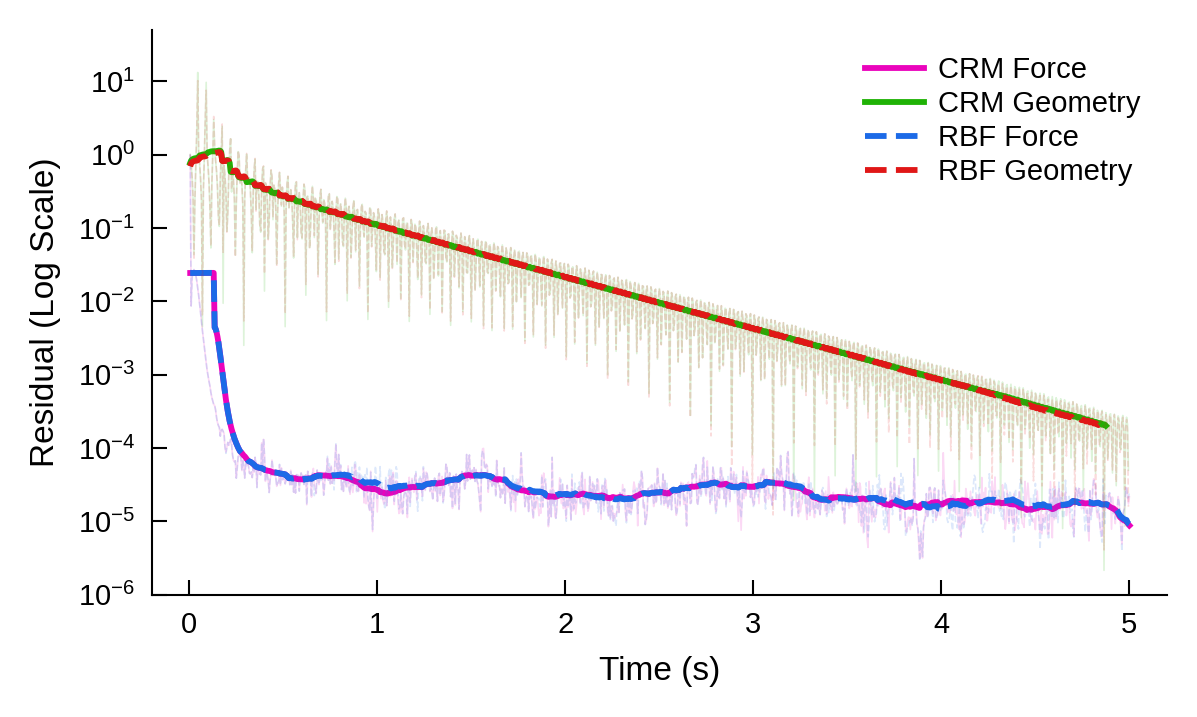

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- 1. Nature Journal Global Style Configuration ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 7,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# --- Color Palette Assignment (Differentiating Force vs Geometry by Color) ---
# Warm tones for CRM, Cool tones for RBF
COLOR_CRM_FORCE = "#EA04BC"     # Magenta
COLOR_CRM_GEOMETRY = "#1FB205"  # Orange / Coral
COLOR_RBF_FORCE = "#1C6AE7"     # Vibrant Blue
COLOR_RBF_GEOMETRY = "#E01717"  # Cyan / Light Blue

# --- 2. Convert Coupling Step to Physical Time ---
dt = 0.005  # s

time_coupling_crm = fluid_coupling_crm["step"] * dt
time_coupling_res = fluid_coupling_res["step"] * dt

# --- Moving Average Helper Function ---
def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')

WINDOW = 50  # Adjust window size here to smooth more or less

# Compute moving averages
crm_f_ma = moving_average(fluid_coupling_crm["force_residual"], WINDOW)
crm_g_ma = moving_average(fluid_coupling_crm["geometry_residual"], WINDOW)
rbf_f_ma = moving_average(fluid_coupling_res["force_residual"], WINDOW)
rbf_g_ma = moving_average(fluid_coupling_res["geometry_residual"], WINDOW)

# --- 3. Setup Figure ---
fig, ax = plt.subplots(figsize=(4.0, 2.4), dpi=300)
ax.set_yscale("log")  # Explicitly set y-axis to log scale

# --- 4. Plot FSI Residuals (Background raw data vs. Bold alpha=1.0 Moving Averages) ---

# --- CRM Force ---
ax.plot(time_coupling_crm, fluid_coupling_crm["force_residual"], color=COLOR_CRM_FORCE, linestyle="-", linewidth=0.4, alpha=0.15)
h_crm_f, = ax.plot(time_coupling_crm, crm_f_ma, color=COLOR_CRM_FORCE, linestyle="-", linewidth=1.4, alpha=1.0)

# --- CRM Geometry ---
ax.plot(time_coupling_crm, fluid_coupling_crm["geometry_residual"], color=COLOR_CRM_GEOMETRY, linestyle="-", linewidth=0.4, alpha=0.15)
h_crm_g, = ax.plot(time_coupling_crm, crm_g_ma, color=COLOR_CRM_GEOMETRY, linestyle="-", linewidth=1.4, alpha=1.0)

# --- RBF Force ---
ax.plot(time_coupling_res, fluid_coupling_res["force_residual"], color=COLOR_RBF_FORCE, linestyle="--", linewidth=0.4, alpha=0.15)
h_rbf_f, = ax.plot(time_coupling_res, rbf_f_ma, color=COLOR_RBF_FORCE, linestyle="--", linewidth=1.4, alpha=1.0)

# --- RBF Geometry ---
ax.plot(time_coupling_res, fluid_coupling_res["geometry_residual"], color=COLOR_RBF_GEOMETRY, linestyle="--", linewidth=0.4, alpha=0.15)
h_rbf_g, = ax.plot(time_coupling_res, rbf_g_ma, color=COLOR_RBF_GEOMETRY, linestyle="--", linewidth=1.4, alpha=1.0)

# --- 5. Axes ---
ax.set_xlabel("Time (s)", labelpad=4)
ax.set_ylabel("Residual (Log Scale)", labelpad=4)

ax.set_xlim(-0.2, 5.2)
ax.set_ylim(1e-6, 5e1)

ax.set_xticks([0, 1, 2, 3, 4, 5])

ax.tick_params(axis="both", which="major", length=3.5, pad=4)
ax.tick_params(axis="y", which="minor", length=2.0, left=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# --- 6. Legend ---
ax.legend(
    handles=[h_crm_f, h_crm_g, h_rbf_f, h_rbf_g],
    labels=["CRM Force", "CRM Geometry", "RBF Force", "RBF Geometry"],
    frameon=False,
    loc="upper right",
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.5
)

# --- 7. Export ---
fig.tight_layout()
fig_dir = Path(FIG_DIR) if "FIG_DIR" in locals() else Path(".")
fig.savefig(fig_dir / "fsi_coupling_residuals.pdf", bbox_inches="tight", transparent=True)
plt.show()
